In [2]:
from neofit_test_utils import time_test, plot_runtime_heatmaps, compare_original, time_neofit, plot_feature_significance, plot_multiple_feature_significance
import numpy as np
from treeple.datasets import make_trunk_classification
from sklearn.model_selection import train_test_split
from neofit import NeuroExplainableOptimalFIT

/home/clark/anaconda3/envs/ydf/lib/python3.10/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.29.1 is exactly one major version older than the runtime version 6.31.1 at yggdrasil_decision_forests/dataset/data_spec.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/home/clark/anaconda3/envs/ydf/lib/python3.10/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.29.1 is exactly one major version older than the runtime version 6.31.1 at yggdrasil_decision_forests/dataset/weight.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/home/clark/anaconda3/envs/ydf/lib/python3.10/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.29.1 is exactly one major version older than the runtime version 6.31.1 at yggdrasil_decision_forests/learner/abstract_l

# Compare feature significance using [cpu_numba, cpu, cuda]

In [3]:
n_samples = 1000
n_dim = 784
X_trunk, y_trunk = make_trunk_classification(n_samples=n_samples, n_dim=n_dim, n_informative=600, seed=0)
print(X_trunk.shape, y_trunk.shape)

X_train_trunk, X_temp_trunk, y_train_trunk, y_temp_trunk = train_test_split(X_trunk, y_trunk, test_size=0.4, random_state=0)
X_val_trunk, X_test_trunk, y_val_trunk, y_test_trunk = train_test_split(X_temp_trunk, y_temp_trunk, test_size=0.5, random_state=0)

print(X_train_trunk.shape, X_val_trunk.shape, X_test_trunk.shape)
print(y_train_trunk.shape, y_val_trunk.shape, y_test_trunk.shape)

(1000, 784) (1000,)
(600, 784) (200, 784) (200, 784)
(600,) (200,) (200,)


In [ ]:
# CUDA
neofit1 = NeuroExplainableOptimalFIT(n_estimators=5000, 
                                    n_permutations=100000, 
                                    clf_type="SPORF",
                                    device='cuda',
                                    verbose=False,)
p_values1, _, _ = neofit1.get_significant_features(X_train_trunk, y_train_trunk)

# CPU
neofit2 = NeuroExplainableOptimalFIT(n_estimators=5000, 
                                    n_permutations=100000, 
                                    clf_type="SPORF",
                                    device='cpu',
                                    verbose=False,)
p_values2, _, _ = neofit2.get_significant_features(X_train_trunk, y_train_trunk)

# CPU numba
neofit3 = NeuroExplainableOptimalFIT(n_estimators=5000, 
                                    n_permutations=100000, 
                                    clf_type="SPORF",
                                    device='cpu_numba',
                                    verbose=False,)
p_values3, _, _ = neofit3.get_significant_features(X_train_trunk, y_train_trunk)

Training forest with 5000 trees on original data...


100%|██████████| 5000/5000 [00:04<00:00, 1084.74it/s]


Time taken for training on original data: 4.98 seconds
Training forest with 5000 trees on shuffled data...


100%|██████████| 5000/5000 [00:02<00:00, 1872.45it/s]


Time taken for training on shuffled data: 3.08 seconds
Computing p-values with 100000 permutations...
Time taken for null_stat computation: 18.53 seconds
Time taken for get_p(): 18.89 seconds
Total time for feat_imp_test(): 26.95 seconds
Found 19 significant features out of 784
Training forest with 5000 trees on original data...


...

Time taken for training on shuffled data: 3.14 seconds
Computing p-values with 100000 permutations...
Time taken for null_stat computation: 216.96 seconds
Time taken for get_p(): 217.35 seconds
Total time for feat_imp_test(): 223.54 seconds
Found 17 significant features out of 784
Training forest with 5000 trees on original data...


100%|██████████| 5000/5000 [00:02<00:00, 1949.10it/s]


Time taken for training on original data: 2.98 seconds
Training forest with 5000 trees on shuffled data...


100%|██████████| 5000/5000 [00:02<00:00, 1918.16it/s]


Time taken for training on shuffled data: 3.05 seconds
Computing p-values with 100000 permutations...
Time taken for null_stat computation: 10.66 seconds
Time taken for get_p(): 11.06 seconds
Total time for feat_imp_test(): 17.08 seconds
Found 18 significant features out of 784


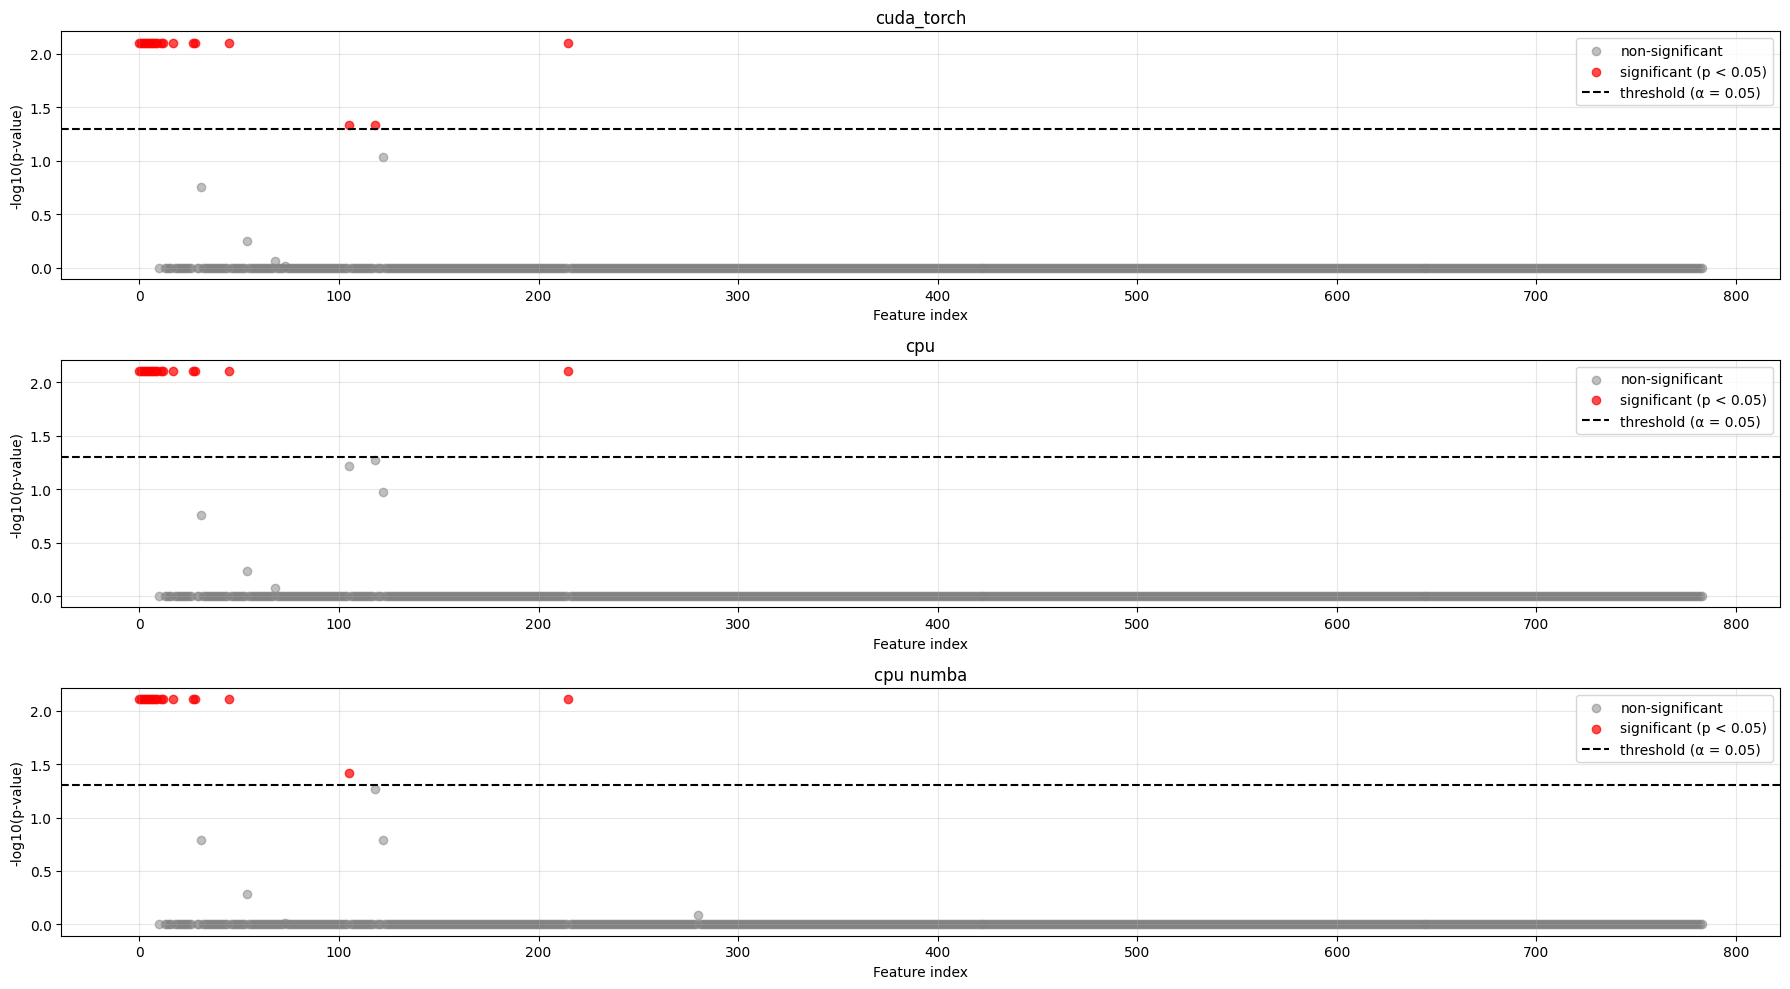

In [6]:
plot_multiple_feature_significance([p_values1, p_values2, p_values3], ['cuda_torch','cpu', 'cpu numba'], ncols=1)

# Compare original/numba cpu/gpu sporf neofit

In [ ]:
dim_range=np.array([256, 512, 1024, 2048])
sample_range=dim_range
#(np.ones(len(dim_range))*1000).astype(int)

time_neofit(dim_range, 
        sample_range, 
        clf_type="SPORF", 
        n_permutations=10000,
        n_estimators=5000,
        devices=['cpu_numba','cpu','cuda'],
        save_result=True,
        result_path="results/neofit_sporf_all_device_compare_10e4_perm.csv")

Saved plot to: results/neofit_sporf_all_device_compare_10e4_perm


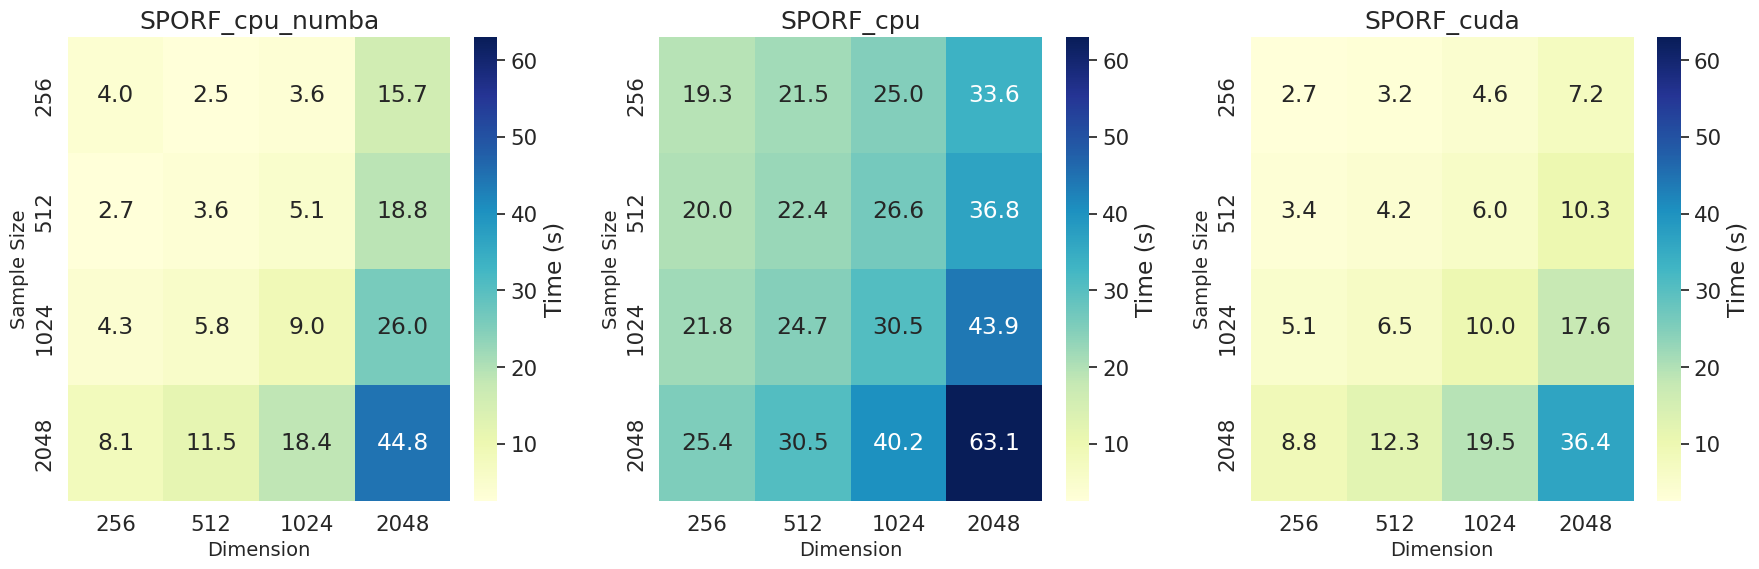

In [9]:
import pandas as pd
df = pd.read_csv("results/neofit_sporf_all_device_compare_10e4_perm.csv")
plot_runtime_heatmaps(
    df=df,
    save_path="results/neofit_sporf_all_device_compare_10e4_perm",
    #titles=['SPORF_cpu', 'SPORF_cpu_numba','SPORF_cuda'],
    cmap = "YlGnBu",
    figsize = None,
    font_scale = 1.4,
    fmt = ".1f"
)

In [ ]:
dim_range=np.array([256, 512, 1024, 2048])
sample_range=dim_range

time_neofit(dim_range, 
        sample_range, 
        clf_type="SPORF", 
        n_permutations=100000,
        n_estimators=5000,
        devices=['cpu_numba','cpu','cuda'],
        save_result=True,
        result_path="results/neofit_sporf_all_device_compare_10e5_perm.csv")

Saved plot to: results/neofit_sporf_all_device_compare_10e5_perm


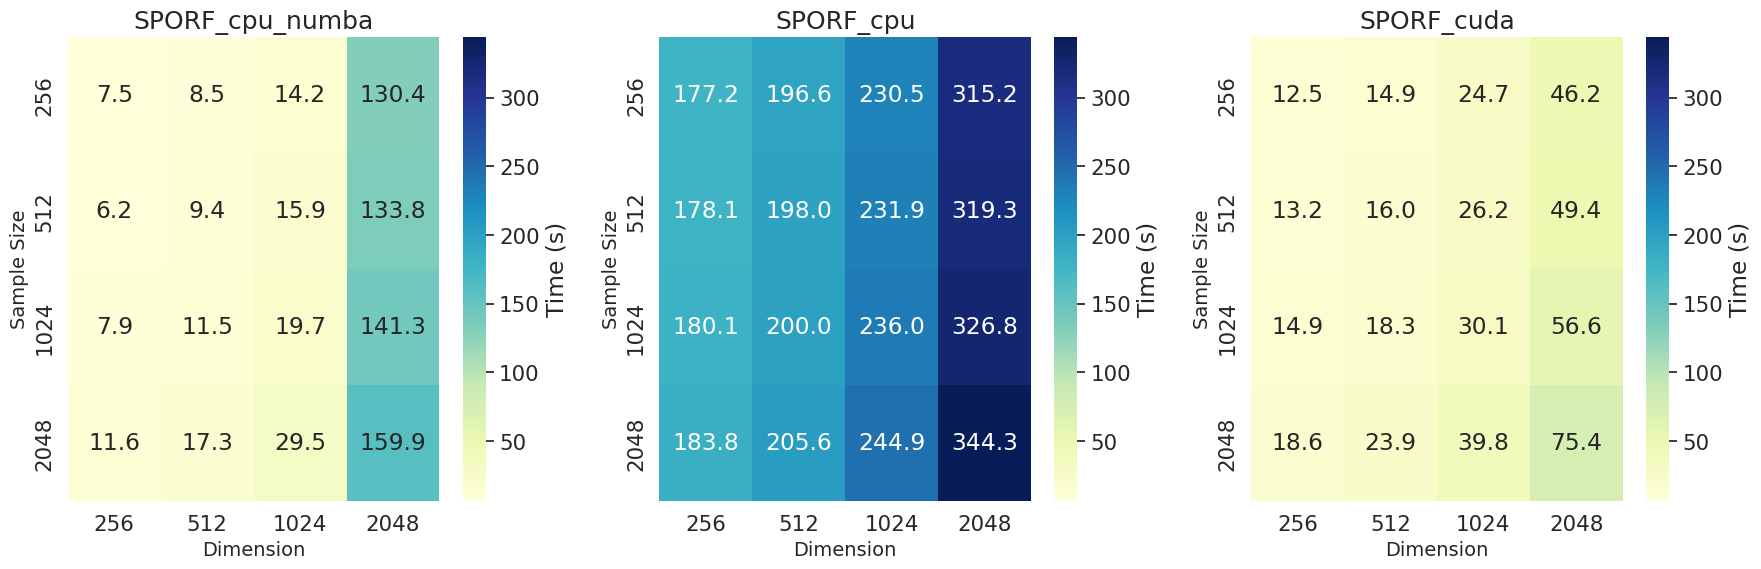

In [5]:
import pandas as pd
df = pd.read_csv("results/neofit_sporf_all_device_compare_10e5_perm.csv")
plot_runtime_heatmaps(
    df=df,
    save_path="results/neofit_sporf_all_device_compare_10e5_perm",
    #titles=['SPORF_cpu_numba', 'SPORF_cpu','SPORF_cuda'],
    cmap = "YlGnBu",
    figsize = None,
    font_scale = 1.4,
    fmt = ".1f"
)

In [ ]:
dim_range=np.array([256, 512])
sample_range=dim_range

result = time_neofit(dim_range, 
        sample_range, 
        clf_type="SPORF", 
        n_permutations=100000,
        n_estimators=5000,
        devices=['cpu_numba','cpu','cuda','cpu_numba_paired'],
        save_result=False,
        result_path="results/neofit_sporf_all_device_compare_10e5_perm.csv")

In [6]:
result

,dim,sample,time,type,n_significant
0,256,256,7.423674,SPORF_cpu_numba,14
1,256,256,175.257373,SPORF_cpu,14
2,256,256,11.966408,SPORF_cuda,14
3,256,256,13.331006,SPORF_cpu_numba_paired,14
4,256,512,6.142376,SPORF_cpu_numba,16
5,256,512,175.987364,SPORF_cpu,14
6,256,512,12.618496,SPORF_cuda,16
7,256,512,13.957696,SPORF_cpu_numba_paired,15
8,512,256,8.635657,SPORF_cpu_numba,10
9,512,256,195.211883,SPORF_cpu,9


In [ ]:
import pandas as pd
#df = pd.read_csv("results/neofit_sporf_all_device_compare_10e5_perm.csv")
plot_runtime_heatmaps(
    df=result,
    save_path="results/neofit_sporf_all_device_compare_10e5_perm",
    #titles=['SPORF_cpu_numba', 'SPORF_cpu','SPORF_cuda'],
    cmap = "YlGnBu",
    figsize = None,
    font_scale = 1.4,
    fmt = ".1f"
)

# Compare original neofit to numba rng neofit (cpu)

In [3]:
dim_range=np.array([256, 512, 1024])
sample_range=dim_range


compare_original(dim_range, 
        sample_range, 
        clf_type="SPORF", 
        n_permutations=10000,
        n_estimators=5000,
        device1='cpu_numba',
        device2='cpu',
        save_result=False,
        result_path="results/neofit_device_compare2.csv")

Training forest with 5000 trees on original data...


100%|██████████| 5000/5000 [00:02<00:00, 2147.00it/s]


Time taken for training on original data: 2.58 seconds
Training forest with 5000 trees on shuffled data...


100%|██████████| 5000/5000 [00:00<00:00, 12949.78it/s]


Time taken for training on shuffled data: 0.65 seconds
Computing p-values with 10000 permutations...
Time taken for null_stat computation: 1.21 seconds
Time taken for get_p(): 1.48 seconds
Total time for feat_imp_test(): 4.72 seconds
Found 14 significant features out of 256
Training forest with 5000 trees on original data...


...

100%|██████████| 5000/5000 [00:03<00:00, 1619.12it/s]


Time taken for training on original data: 3.56 seconds
Training forest with 5000 trees on shuffled data...


100%|██████████| 5000/5000 [00:03<00:00, 1574.10it/s]


Time taken for training on shuffled data: 3.65 seconds
Computing p-values with 10000 permutations...
Time taken for statisitcs: 0.01 seconds
Time taken for statisitcs: 22.77 seconds
Time taken for get_p(): 23.09 seconds
Total time for feat_imp_test(): 30.31 seconds
Found 0 significant features out of 1024
Feature diff (imp2 - imp1) for dim=1024, sample=1024: 0


,dim,sample,time,type
0,256,256,4.721947,SPORF_cpu_numba_numba
1,256,256,19.063367,SPORF_cpu_original
2,256,512,2.663092,SPORF_cpu_numba_numba
3,256,512,19.728317,SPORF_cpu_original
4,256,1024,4.476015,SPORF_cpu_numba_numba
5,256,1024,21.476597,SPORF_cpu_original
6,512,256,2.463406,SPORF_cpu_numba_numba
7,512,256,21.149964,SPORF_cpu_original
8,512,512,3.536673,SPORF_cpu_numba_numba
9,512,512,22.406592,SPORF_cpu_original


# Compare CUDA and CPU SPORF neofit

In [ ]:

dim_range=np.array([256, 512, 1024, 2048])
sample_range=dim_range


time_test(dim_range, 
        sample_range, 
        clf_type="SPORF", 
        n_permutations=10000,
        n_estimators=5000,
        device1='cuda',
        device2='cpu',
        save_result=True,
        result_path="results/neofit_device_compare1.csv")

# Compare CUDA and CPU MORF Neofit

In [11]:
dim_range=np.array([256, 512, 1024, 2048])
data_dims = (np.array((16,16)), np.array((32,16)), np.array((32,32)), np.array((64,32)))
len(dim_range)

4

In [3]:

dim_range=np.array([256, 512, 1024, 2048])
data_dims = (np.array((16,16)), np.array((32,16)), np.array((32,32)), np.array((64,32)))
sample_range=dim_range


time_test(dim_range, 
        sample_range, 
        clf_type="MORF", 
        n_permutations=10000,
        n_estimators=5000,
        device1='cuda',
        device2='cpu',
        max_patch_dims=np.array((2,2)),
        min_patch_dims=None,
        data_dims=data_dims,
        save_result=False,
        result_path="results/neofit_device_compare.csv")

Training forest with 5000 trees on original data...


100%|██████████| 5000/5000 [00:02<00:00, 1821.64it/s]


Time taken for training on original data: 3.11 seconds
Training forest with 5000 trees on shuffled data...


100%|██████████| 5000/5000 [00:00<00:00, 11861.92it/s]


Time taken for training on shuffled data: 0.74 seconds
Computing p-values with 10000 permutations...
Time taken for null_stat computation: 1.23 seconds
Time taken for get_p(): 1.50 seconds
Total time for feat_imp_test(): 5.35 seconds
Found 34 significant features out of 256
Training forest with 5000 trees on original data...


...

100%|██████████| 5000/5000 [00:16<00:00, 311.76it/s]


Time taken for training on original data: 16.61 seconds
Training forest with 5000 trees on shuffled data...


100%|██████████| 5000/5000 [00:16<00:00, 298.50it/s]


Time taken for training on shuffled data: 17.34 seconds
Computing p-values with 10000 permutations...
Time taken for null_stat computation: 30.53 seconds
Time taken for get_p(): 30.92 seconds
Total time for feat_imp_test(): 64.88 seconds
Found 0 significant features out of 2048
Feature diff (imp2 - imp1) for dim=2048, sample=2048: 0


,dim,sample,time,type
0,256,256,5.354372,MORF_cuda
1,256,256,20.722233,MORF_cpu
2,256,512,3.654224,MORF_cuda
3,256,512,20.325213,MORF_cpu
4,256,1024,5.707236,MORF_cuda
5,256,1024,22.346103,MORF_cpu
6,256,2048,10.590129,MORF_cuda
7,256,2048,27.093074,MORF_cpu
8,512,256,3.378132,MORF_cuda
9,512,256,21.624326,MORF_cpu


In [8]:

dim_range=np.array([256, 512, 1024, 2048])
sample_range=dim_range


time_test(dim_range, 
        sample_range, 
        clf_type="MORF", 
        n_permutations=10000,
        n_estimators=5000,
        device1='cuda',
        device2='cpu',
        save_result=True,
        result_path="results/neofit_device_compare.csv")

Training forest with 5000 trees on original data...
















  1%|          | 31/5000 [03:40<9:49:14,  7.12s/it]


Time taken for training on original data: 2.85 seconds
Training forest with 5000 trees on shuffled data...


100%|██████████| 5000/5000 [00:01<00:00, 4196.11it/s]


Time taken for training on shuffled data: 1.51 seconds
Computing p-values with 10000 permutations...
Time taken for null_stat computation: 1.18 seconds
Time taken for get_p(): 1.44 seconds
Total time for feat_imp_test(): 5.80 seconds
Found 86 significant features out of 256
Training forest with 5000 trees on original data...


...

100%|██████████| 5000/5000 [02:25<00:00, 34.32it/s]


Time taken for training on original data: 146.80 seconds
Training forest with 5000 trees on shuffled data...


100%|██████████| 5000/5000 [03:05<00:00, 26.96it/s]


Time taken for training on shuffled data: 186.94 seconds
Computing p-values with 10000 permutations...
Time taken for null_stat computation: 30.14 seconds
Time taken for get_p(): 30.67 seconds
Total time for feat_imp_test(): 364.42 seconds
Found 0 significant features out of 2048
Feature diff (imp2 - imp1) for dim=2048, sample=2048: 0


,dim,sample,time,type
0,256,256,5.804043,MORF_cuda
1,256,256,20.562961,MORF_cpu
2,256,512,6.196193,MORF_cuda
3,256,512,22.723598,MORF_cpu
4,256,1024,11.527055,MORF_cuda
5,256,1024,27.932824,MORF_cpu
6,256,2048,24.439053,MORF_cuda
7,256,2048,40.946157,MORF_cpu
8,512,256,6.560120,MORF_cuda
9,512,256,24.719734,MORF_cpu


Saved plot to: results/neofit_morf_compare


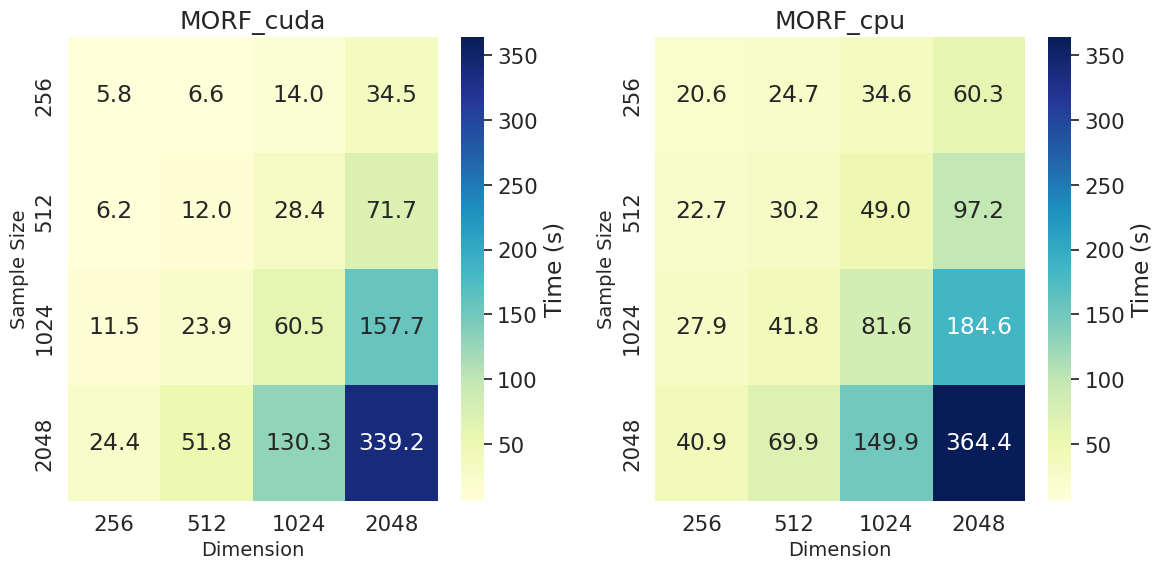

In [3]:
import pandas as pd


df = pd.read_csv("results/neofit_morf_compare.csv")

plot_runtime_heatmaps(df,
    save_path='results/neofit_morf_compare',
    titles = None,
)